---
# Exploratory Data Analysis: 
## Spotify Tracks Dataset
Gage Fulwood | gtf53

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATASET = "spotify-tracks-dataset-detailed.csv"

## 1. Dataset Loading
To begin my exploratory data analysis, I first need to load the dataset itself and view its contents. I am specifically looking at the rows, colummns, features, and provided data types.

In [2]:
# Load Dataset
df = pd.read_csv(DATASET)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

#### Interpretation
The dataset has 114,000 rows and 20 columns.
Each column falls into one of three groups:
- Identifiers: `track_id`, `artists`, `album_name`, `track_name`.
- Categorical: `track_genre` (114 genres), `explicit` (boolean), and musical elements like `key`, `mode`, and `time_signature` (not continous quantities, just small int sets)
- Numerical Audio Features: `danceability`, `energy`, `loudness`, `speechiness`, `accousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_ms`, and the target variable `popularity`.

<p>I need to not treat `key` or `time_signature` as continuous, otherwise analysis could be skewed between real numeric data and encoded data.</p>

---

## 2. Summarizing Statistics
To summarize the numerical features of the dataset I used `describe()`, which helps me understand spreads, ranges, and centers to summarize the non-numerical columns independently.

In [4]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
df.describe(include=["object", "bool"])

/var/folders/vj/03h5j0rn0_j_4l1135jfjp880000gn/T/ipykernel_55763/3870744420.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object", "bool"])


,track_id,artists,album_name,track_name,explicit,track_genre
count,114000,113999,113999,113999,114000,114000
unique,89741,31437,46589,73608,2,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,False,acoustic
freq,9,279,195,151,104253,1000


#### Interpretation
- Target Variable (`popularity`): mean = 33, median = 35, std = 22, ranging from 0-100.
- Suspicious Minimums: `duration_ms` has a minimum of 0 (tracks cannot be 0ms long). `tempo` reaches 0 (also should not be possible).
- Extreme Maximums: `duration_ms` reaches 5,237,295 ms, which is nearly 87 minutes long. Could cause heavy skewing.
- Bounded Features: `danceability`, `energy`, `valence` live in a range of 0-1, but `loudness` is in decibels (negatives) and `tempo` is in BPM. Those features operate on completey different scales. 
---

## 3. Missing Data
Missing values can ruin the quality of the data and potential models themselves, so I am counting null entries per column, then inspecting the affected rows.

In [6]:
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nTotal rows with at least one missing value:", df.isnull().any(axis=1).sum())

artists       1
album_name    1
track_name    1
dtype: int64

Total rows with at least one missing value: 1


In [7]:
df[df.isnull().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


#### Interpretation
<p>Only one row is missing `artists`, `album_name`, and `track_name`. More importantly, for that track none of the important audio features or the target are missing. Since only one row is affected and the data tied to it is not meaningful, it would probably be smart to drop this row.</p>

---

## 4. Duplicate Records
`track_id` needs to be a unique identifier for a song, so I am checking if the IDs repeat and making sure no rows are duplicates.

In [9]:
dupes_full = df.duplicated().sum()
dupes_id = df.duplicated(subset="track_id").sum()
print("Entirely duplicated rows:", dupes_full)
print("Rows sharing `track_id` with another:", dupes_id)

# How many repeating `track_id`'s are under more than one genre
multi = df[df.duplicated(subset="track_id", keep=False)]
spans = multi.groupby("track_id")["track_genre"].nunique()
print("Repeated `track_id`'s appearing as >1 genre:", 
      int((spans > 1).sum()), "of", spans.shape[0])

Entirely duplicated rows: 450
Rows sharing `track_id` with another: 24259
Repeated `track_id`'s appearing as >1 genre: 16299 of 16641


#### Interpretation
<p>
Duplicate track records seems to be the most substantial data-quality issue present in the dataset. 24,259 rows have the same `track_id` as another row, with 450 rows being exact duplicates of another track entirely.
</p>

---

## 5. Target Variable Distribution
I am plotting the distribution for `popularity` so i can understand the shape of what is trying to be predicted, which can help determine what model to use later on.

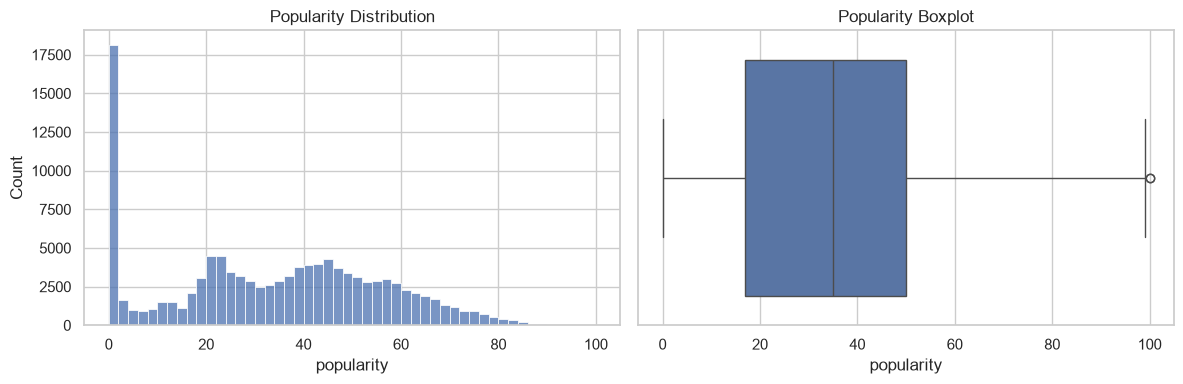

Tracks where `popularity` equals 0:  14.1%


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["popularity"], bins=50, ax=ax[0])
ax[0].set_title("Popularity Distribution")
sns.boxplot(x=df["popularity"], ax=ax[1])
ax[1].set_title("Popularity Boxplot")
plt.tight_layout()
plt.show()

print("Tracks where `popularity` equals 0: ", f"{(df['popularity'] == 0).mean() * 100:.1f}%")

#### Interpretation
<p>
The target variable is right-skewed and has an extreme spike at 0, with 14% of all tracks in the dataset having a `popularity` of zero. This is likely the floor for new or obscure tracks in spotify's dataset and does not indicate it literally is not popular. 
</p>

---

## 6. Audio Features Distributions

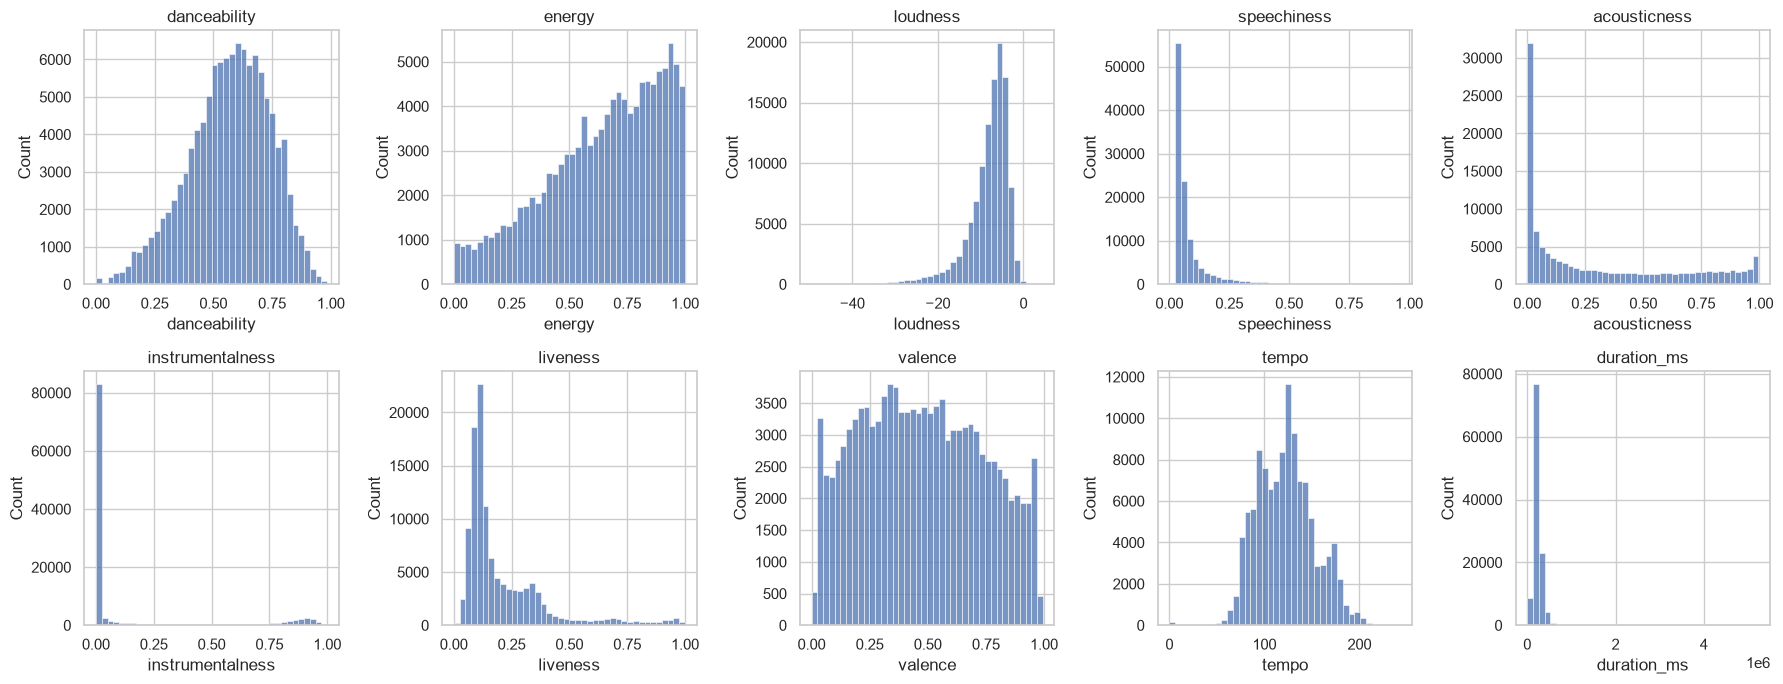

Feature Skewness (sorted):
loudness            -2.006542
energy              -0.597001
danceability        -0.399497
valence              0.115078
tempo                0.232295
acousticness         0.727295
instrumentalness     1.734406
liveness             2.105738
speechiness          4.647516
duration_ms         11.195181
dtype: float64


In [12]:
feature_cols = ["danceability", "energy", "loudness", "speechiness",
                "acousticness", "instrumentalness", "liveness",
                "valence", "tempo", "duration_ms"]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Feature Skewness (sorted):")
print(df[feature_cols].skew().sort_values())

#### Interpretation
<p>
Features appear to have very different shapes. `duration_ms`, `speechiness`, `liveness`, `instrumentalness`, and `acousticness` are heavily right-skewed while `loudness` is left-skewed. On the other hand, `danceability`, `energy`, `valence`, and `tempo` are fairly symmetric. Lastly, `instrumentalness` is bimodal.
</p>

---

## 7. Outlier Detection

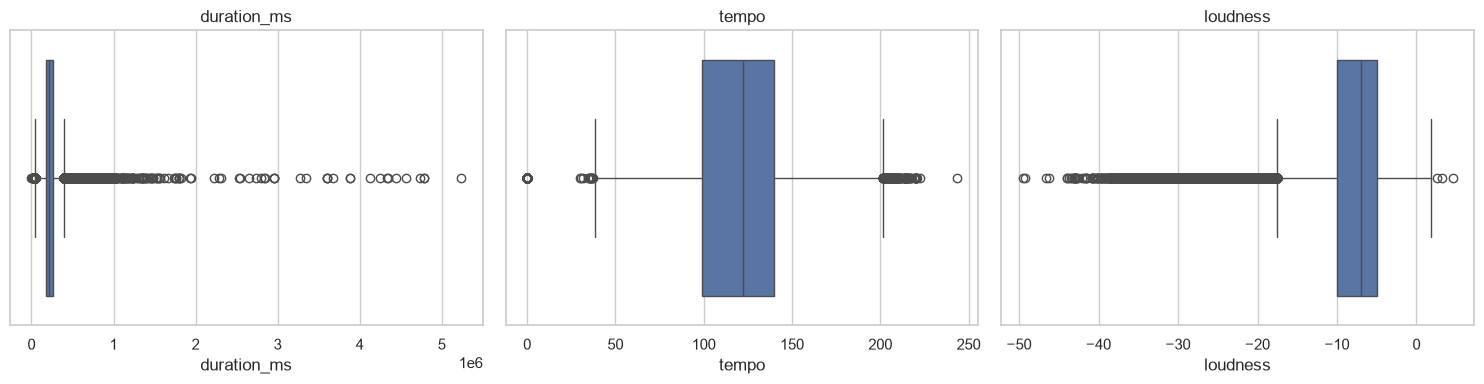

Tracks where `duration_ms` equals 0: 1
Tracks where `tempo` equals 0: 157
Tracks where `time_signature` equals 0: 163
Longest duration track (in minutes): 872.9


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=df["duration_ms"], ax=ax[0]); ax[0].set_title("duration_ms")
sns.boxplot(x=df["tempo"], ax=ax[1]); ax[1].set_title("tempo")
sns.boxplot(x=df["loudness"], ax=ax[2]); ax[2].set_title("loudness")
plt.tight_layout()
plt.show()

print("Tracks where `duration_ms` equals 0:", int((df["duration_ms"] == 0).sum()))
print("Tracks where `tempo` equals 0:", int((df["tempo"] == 0).sum()))
print("Tracks where `time_signature` equals 0:", int((df["time_signature"] == 0).sum()))
print("Longest duration track (in minutes):", round(df["duration_ms"].max() / 6000, 1))

#### Interpretation
<p>
Invalid values in the dataset would be `duration_ms` == 0, `tempo` == 0 (157 results), and `time_signature` == 0 (163 results). Therefore, any invalid values need to be removed.

`duration_ms` shows a long tail that goes up to 87 minutes and `loudness` has a tail of quiet tracks. Though these are outliers, their values are plausible. Maybe flag them.
</p>

---

## 8. Correlation Analysis
To find feature-target relationships, I am computing the linear correlations for the numeric features, specifically in accordance with each feature's correlation to the target `popularity`. I am excluding `key`, `mode`, and `time_signature` as discussed earlier.

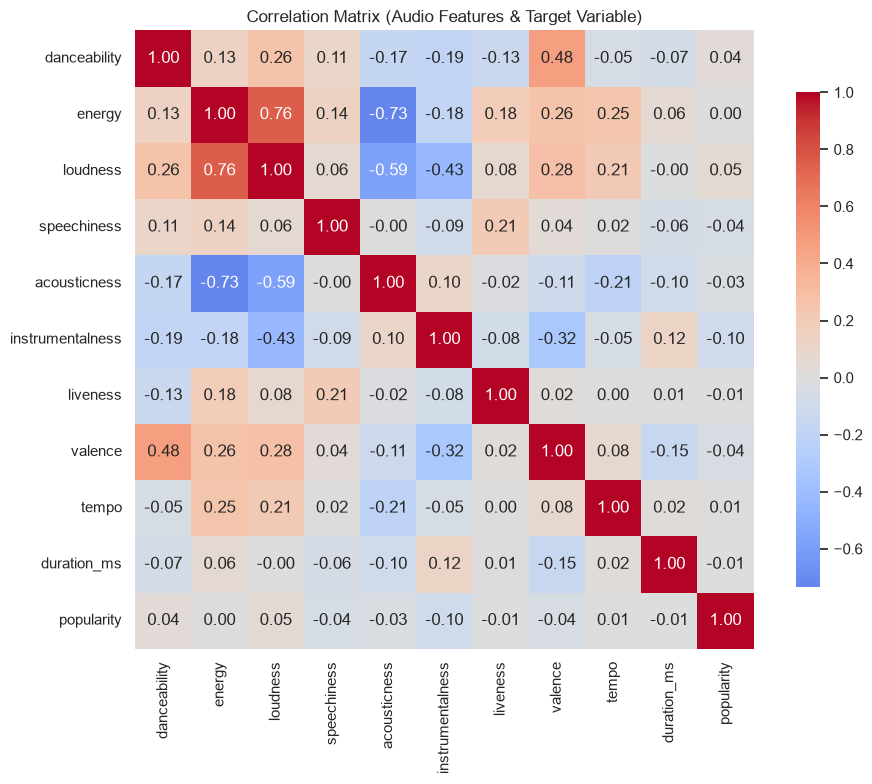

In [14]:
num_cols = feature_cols + ["popularity"]
correlation = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (Audio Features & Target Variable)")
plt.tight_layout()
plt.show()

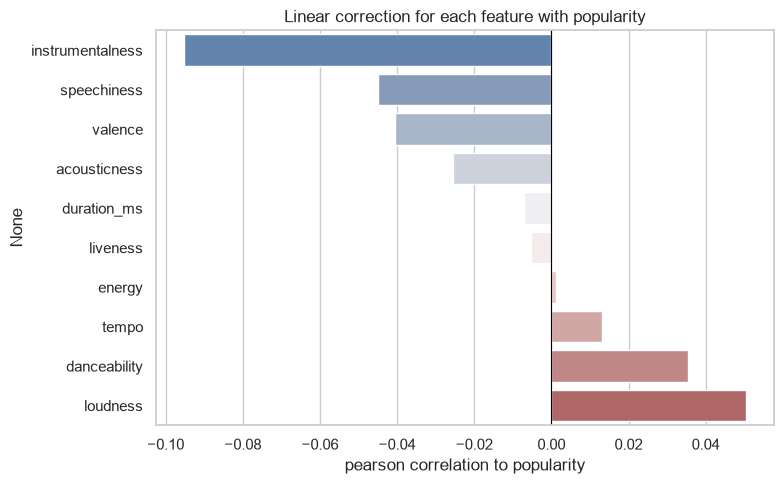

instrumentalness   -0.095139
loudness            0.050423
speechiness        -0.044927
valence            -0.040534
danceability        0.035448
acousticness       -0.025472
tempo               0.013205
duration_ms        -0.007101
liveness           -0.005387
energy              0.001056
Name: popularity, dtype: float64


In [15]:
target_correlation = correlation["popularity"].drop("popularity").sort_values()
plt.figure(figsize=(8, 5))
sns.barplot(x=target_correlation.values, y=target_correlation.index, hue=target_correlation.index,
            palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear correction for each feature with popularity")
plt.xlabel("pearson correlation to popularity")
plt.tight_layout()
plt.show()

print(target_correlation.sort_values(key=abs, ascending=False))

#### Interpretation
<p>
No audio feature is strongly correlated to `popularity` in a linear way. The largest correlation present is 0.10 (absolute value `instrumentalness`), with `loudness`, `valence`, and `speechiness` close behind. 

The most important finding so far is that the audio features themselves carry very little linear indicators of `popularity`. 
</p>

---

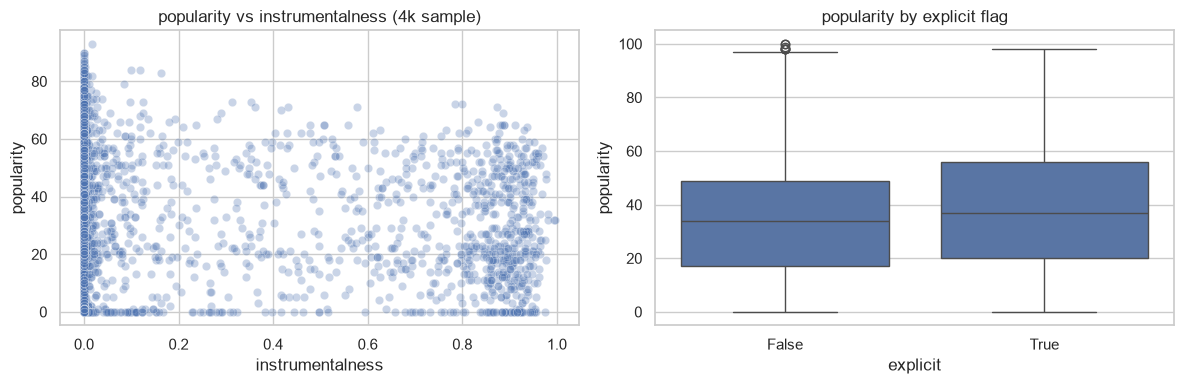

In [17]:
sample = df.sample(4000, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=sample, x="instrumentalness", y="popularity",
                alpha=0.3, ax=ax[0])
ax[0].set_title("popularity vs instrumentalness (4k sample)")
sns.boxplot(data=df, x="explicit", y="popularity", ax=ax[1])
ax[1].set_title("popularity by explicit flag")
plt.tight_layout()
plt.show()

#### Interpretation
<p>
The scatter of `instrumentalness` against `popularity` shows no clear linear or obvious trend. The `explicit` boxplot indicates explicit tracks are only slightly more popular on average, though their distributions overlap significantly.
</p>

---

## 9. Class Balance and Categorical Structure

In [18]:
print("Tracks per genre (min/max/mean):")
print(df["track_genre"].value_counts().describe()[["min", "max", "mean"]])
print("\nexplicit balance:")
print(df["explicit"].value_counts(normalize=True).round(3))

Tracks per genre (min/max/mean):
min     1000.0
max     1000.0
mean    1000.0
Name: count, dtype: float64

explicit balance:
explicit
False    0.914
True     0.086
Name: proportion, dtype: float64


#### Interpretation
<p>
`track_genre` is balanced perfectly, with all 114 genres having exactly 1,000 tracks. Not very convenient since genre is not the target, but is more notably a result of how the dataset creator collected the data (sampling bias possible). `explicit` is imbalanced (91% non-explicit to 9% explicit). Neither variable is my target, but the potential sampling bias for genres helps explain duplicate entries where the same song was re-sampled for all of its genres.
</p>

---

## 10. Findings and Potential Challenges Summary
This Exploratory Data Analysis noted multiple issues that the preprocessing step must solve:
1. Weak feature-target signalling: No audio feature appears to correlate strongly with `popularity`.
2. Duplicate records: ~24,000 rows shared `track_id` and `450` rows contained exact duplicates. Must be combined or removed.
3. Invalid values: `duration_ms` = 0, `tempo` = 0, and `time_signature` = 0 indicate invalid data that needs removal.
4. Skewed features: features are heavily skewed and span a variety of ranges, so the dataset needs to be scaled and transformed.
5. Floor inflation to target: 14% of tracks have a `popularity` of zero, investigate solutions.
6. Non-predictive columns: `artists`, `album_name`, and `track_name` have high-cardinality and need to be encoded and/or droped. `track_id` is an identifer without a signal.
7. Sampling bias: each genre has 1000 tracks, which does not represent the true population of all popular or unpopular music on the platform.
8. Missing data: not an issue, just one row is missing metadata.

## AI Usage Statement
I utilized Antrhopic's Claude to help me understand markdown formatting in jupyter notebooks, refresh me on the libraries syntax (seaborn, np, etc.), and helped me determine how much of the layout I should derive from the example notebook provided in the course.